# Bank Marketing Campaign Analysis & Customer Conversion Prediction
This notebook presents an analysis of the `bankmarketing.csv` dataset, which includes data related to a bank's marketing campaigns. The main goal is to understand customer behavior and predict whether a client will subscribe to a term deposit.

## Objective
The objective of this project is to analyze customer data from a bank marketing campaign and identify factors that influence whether a customer subscribes to a term deposit.

* Analyze customer data to:

    * Understand customer behavior

    * Identify factors affecting term deposit subscription

    * Improve marketing campaign success rate

## Business Goal
Help the bank improve marketing campaigns by:
- Identifying potential customers
- Understanding customer behavior
- Increasing campaign success rate


## Dataset Overview
* Dataset: Bank Marketing Dataset

Key Columns:

Age, Job, Marital Status

Education

Balance

Contact Type

Duration (call time)

Campaign

Previous outcome

Target: y (Yes/No)


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
# Load the dataset
df = pd.read_csv('bankmarketing.csv')

# Display the first few rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
# Check the size of a dataset — specifically the number of rows and columns in a DataFrame

df.shape

(41188, 21)

### Understanding Dataset Structure
We first inspect the column names to understand available features.

In [31]:
df.columns #check column names

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [32]:

# Check for missing values and data types

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

* We used df.isnull().sum() to identify missing values in the dataset. This helps in understanding data quality and deciding how to handle incomplete records before performing analysis.

In [33]:
df.isnull().sum() # Check the missing values from the dataset (Data Cleaning)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

* We checked for missing values using df.isnull().sum(). The result showed that all columns have 0 missing values, indicating that the dataset is complete and no data cleaning was required for missing values.

In [64]:
df = df.drop_duplicates()

In [65]:
print(df['y'].unique())

['no' 'yes']


In [66]:
df['y'] = df['y'].str.strip().str.lower()

In [ ]:

# Summary statistics (EDA)

df.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


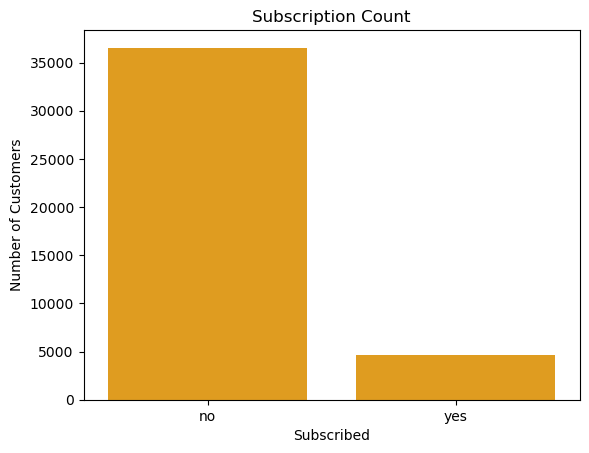

In [11]:

# Plot the distribution of the target variable 
# It shows How many Yes for suscription and how many  for No

sns.countplot(x='y', data=df, color ="orange")
plt.title("Subscription Count")
plt.xlabel("Subscribed")
plt.ylabel("Number of Customers")
plt.show()


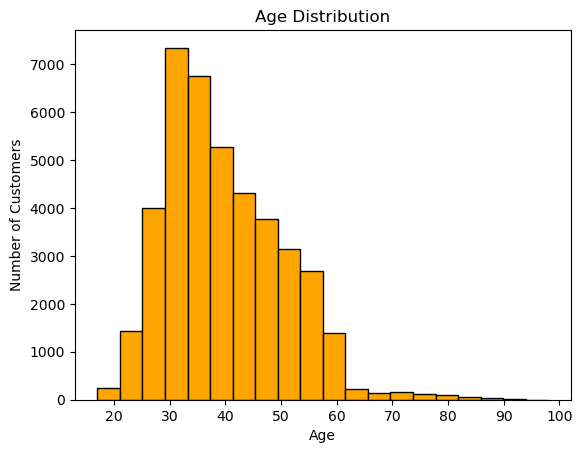

In [15]:
# Age Distribution - It shows which age group people has more and which age group has less customers


plt.hist(df['age'], bins=20, color = "orange", edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")
plt.show()

* Customers aged 30–40 represent the largest segment, indicating that marketing campaigns should prioritize this age group for higher engagement and conversions.
* Very few customers above 60 -
* Customers above 60 years are less represented, suggesting lower engagement from senior citizens.

The age distribution shows that most customers belong to the 30–40 age group, making it the dominant segment. There are fewer customers in higher age groups (above 60), indicating lower participation from senior individuals. This suggests that marketing strategies should primarily focus on middle-aged customers while exploring ways to engage older segments.

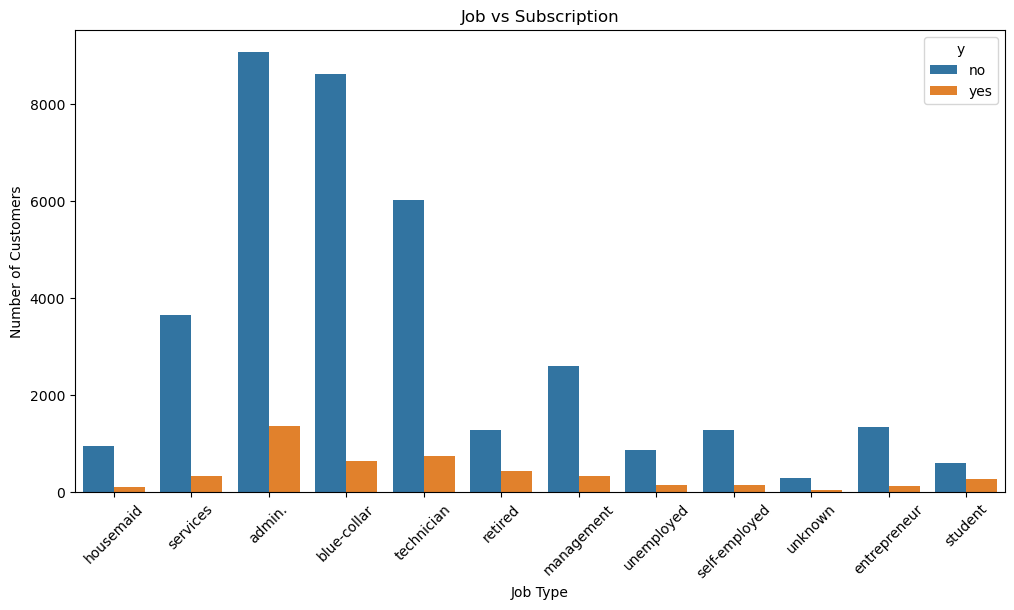

In [72]:

plt.figure(figsize=(12,6))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.xlabel("Job Type")
plt.ylabel("Number of Customers")
plt.title("Job vs Subscription")
plt.show()

* The analysis shows that certain job categories such as students and management have higher subscription rates compared to others. On the other hand, some job groups show lower engagement, indicating that job type plays a significant role in customer response to marketing campaigns.

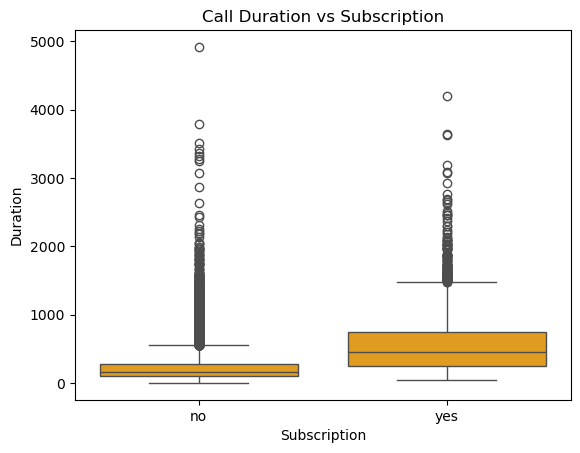

In [12]:

sns.boxplot(x='y', y='duration', data=df, color="orange")

plt.xlabel("Subscription")
plt.ylabel("Duration")
plt.title("Call Duration vs Subscription")

plt.show()

* The boxplot shows a clear difference in call duration between customers who subscribed and those who did not. Customers who subscribed (yes) tend to have significantly longer call durations compared to those who did not subscribe (no). This indicates that higher engagement during calls increases the likelihood of conversion.

In [74]:
df['y'] = df['y'].map({'yes':1, 'no':0})

* Machine learning algorithms require numerical input, so I converted categorical values into binary format.
    * yes = customer subscribed → 1

    * no = customer not subscribed → 0

In [75]:
print(df['y'].head())

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64


* The correlation heatmap shows the relationships between numerical variables. Features like duration show a stronger correlation with the target variable, indicating their importance in predicting customer subscription. Most other variables have weak correlations, suggesting limited direct linear relationships.

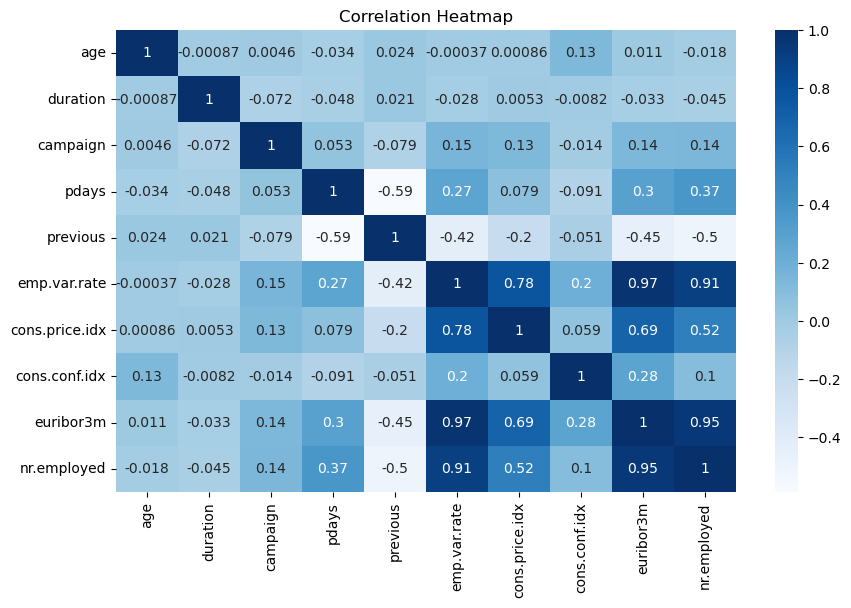

In [13]:
# Correlation matrix for numerical features

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

* I built a Logistic Regression model to predict customer subscription. The dataset was split into training and testing sets, and the model was evaluated using accuracy and confusion matrix to measure performance.

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = df.select_dtypes(include=np.number).drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9056580864497329
Confusion Matrix:
 [[7082  186]
 [ 591  377]]


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 📌 Final Conclusion

This project analyzed the bank marketing dataset to understand customer behavior and evaluate the effectiveness of marketing campaigns in driving term deposit subscriptions.

### 🔍 Key Findings:
- Customers in the **30–40 age group** form the largest segment and show higher engagement with marketing campaigns.  
- Certain job categories (such as professionals and administrative roles) exhibit better conversion rates compared to others.  
- **Call duration** is one of the most influential factors — longer interactions significantly increase the likelihood of subscription.  
- Previous campaign outcomes strongly impact future success, indicating that customers with prior positive responses are more likely to convert again.  
- Contact methods and timing of campaigns also play a role in determining customer response.

### 📊 Business Recommendations:
- Focus marketing efforts on **high-potential customer segments** (mid-age professionals).  
- Optimize **call duration and communication strategy** to improve engagement.  
- Leverage data from **previous successful campaigns** to target likely converters.  
- Personalize campaigns based on customer profile (job, age, past interaction).  

### 🚀 Overall Impact:
The analysis provides actionable insights that can help banks **improve campaign efficiency, increase conversion rates, and make data-driven marketing decisions**.
